# Imported Libraries

In [142]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from sklearn.svm import SVC
##!pip install xlrd
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import pickle
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve

# Data Splitting + EDA

## Dataset Overview

**Name:** Default of Credit Card Clients (UCI Machine Learning Repository)  
**Size:** 30,000 clients × 25 columns (24 features + 1 target)  
**Task:** Binary classification — predict whether a client will default next month

### Feature types

| Group | Columns | Nature |
|---|---|---|
| Target | `default payment next month` | Binary: 1=default, 0=no default |
| Credit info | `LIMIT_BAL` | Continuous — credit limit in NT dollars |
| Demographics | `SEX`, `EDUCATION`, `MARRIAGE`, `AGE` | Categorical/ordinal |
| Repayment status | `PAY_0` to `PAY_6` | Ordinal: -1=on time, 1–8=months delayed |
| Bill amounts | `BILL_AMT1` to `BILL_AMT6` | Continuous — statement amount per month |
| Payment amounts | `PAY_AMT1` to `PAY_AMT6` | Continuous — actual payment made per month |
| Engineered | `TOTAL_DELAY`, `UTILIZATION_RATIO`, `AVG_BILL`, `PAY_RATIO_1` | Derived features |

### Class distribution
- No default (0): ~77.9% (23,364 clients)  
- Default (1): ~22.1% (6,636 clients) → **imbalanced dataset**

## Load Dataset

In [78]:
file_path = r"C:\Users\ayaYM\Downloads\Telegram Desktop\default+of+credit+card+clients\default of credit card clients.xls"
df = pd.read_excel(file_path, header=1, engine='xlrd')
print(df.shape)
df.head()

(30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [79]:
df.columns.tolist()

['ID',
 'LIMIT_BAL',
 'SEX',
 'EDUCATION',
 'MARRIAGE',
 'AGE',
 'PAY_0',
 'PAY_2',
 'PAY_3',
 'PAY_4',
 'PAY_5',
 'PAY_6',
 'BILL_AMT1',
 'BILL_AMT2',
 'BILL_AMT3',
 'BILL_AMT4',
 'BILL_AMT5',
 'BILL_AMT6',
 'PAY_AMT1',
 'PAY_AMT2',
 'PAY_AMT3',
 'PAY_AMT4',
 'PAY_AMT5',
 'PAY_AMT6',
 'default payment next month']

## Train / Test Split

In [80]:
train, test = train_test_split(
    df,
    test_size=0.3,
    random_state=0,
    stratify=df['default payment next month']  # target
)

train = train.copy()
test = test.copy()

train.shape, test.shape

((21000, 25), (9000, 25))

## Exploratory Data Analysis (EDA)

### Dataset Overview

In [81]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 21000 entries, 25149 to 18048
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   ID                          21000 non-null  int64
 1   LIMIT_BAL                   21000 non-null  int64
 2   SEX                         21000 non-null  int64
 3   EDUCATION                   21000 non-null  int64
 4   MARRIAGE                    21000 non-null  int64
 5   AGE                         21000 non-null  int64
 6   PAY_0                       21000 non-null  int64
 7   PAY_2                       21000 non-null  int64
 8   PAY_3                       21000 non-null  int64
 9   PAY_4                       21000 non-null  int64
 10  PAY_5                       21000 non-null  int64
 11  PAY_6                       21000 non-null  int64
 12  BILL_AMT1                   21000 non-null  int64
 13  BILL_AMT2                   21000 non-null  int64
 14  BILL_AM

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
count,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000,21000.00000,21000.000000,21000.000000,21000.00000,...,21000.000000,21000.000000,21000.000000,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,14949.183667,167214.746667,1.607571,1.854190,1.551714,35.461619,-0.01119,-0.127238,-0.164857,-0.21819,...,43387.372476,40398.551095,38931.194000,5686.349333,5.923003e+03,5202.325333,4793.172000,4797.012952,5211.736762,0.221190
std,8632.775153,128965.188482,0.488303,0.791628,0.521176,9.206628,1.12321,1.198957,1.198624,1.17221,...,64081.073110,60396.811177,59196.499234,16868.075695,2.390953e+04,17006.416467,15467.403159,15270.031988,17698.795697,0.415058
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.00000,-2.000000,-2.000000,-2.00000,...,-170000.000000,-81334.000000,-209051.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,7508.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.00000,-1.000000,-1.000000,-1.00000,...,2332.000000,1759.000000,1242.750000,998.250000,8.360000e+02,390.000000,284.000000,241.000000,102.000000,0.000000
50%,14939.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.00000,0.000000,0.000000,0.00000,...,19158.500000,18266.500000,17203.500000,2100.000000,2.011000e+03,1811.500000,1500.000000,1500.000000,1500.000000,0.000000
75%,22386.750000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.00000,0.000000,0.000000,0.00000,...,55376.750000,50517.250000,49463.000000,5023.250000,5.000000e+03,4500.000000,4002.250000,4051.000000,4000.000000,0.000000
max,29998.000000,800000.000000,2.000000,6.000000,3.000000,75.000000,8.00000,8.000000,8.000000,8.00000,...,706864.000000,587067.000000,699944.000000,873552.000000,1.684259e+06,889043.000000,621000.000000,417990.000000,528666.000000,1.000000


In [82]:
train.isnull().sum()

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64

### Target Distribution

In [83]:

train['default payment next month'].value_counts(normalize=True)

default payment next month
0    0.77881
1    0.22119
Name: proportion, dtype: float64

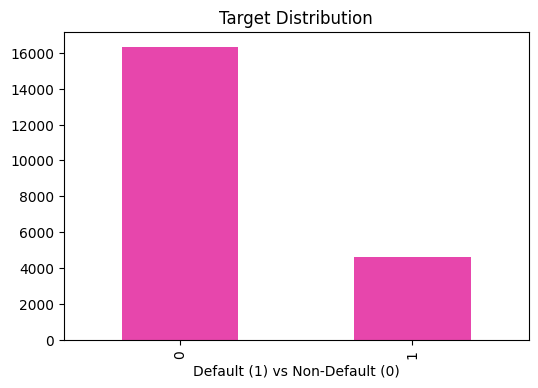

In [84]:
plt.figure(figsize=(6,4))
train['default payment next month'].value_counts().plot(
    kind='bar',
    color='#e746ac'
)
plt.title('Target Distribution')
plt.xlabel('Default (1) vs Non-Default (0)')
plt.show()

### Feature Distributions

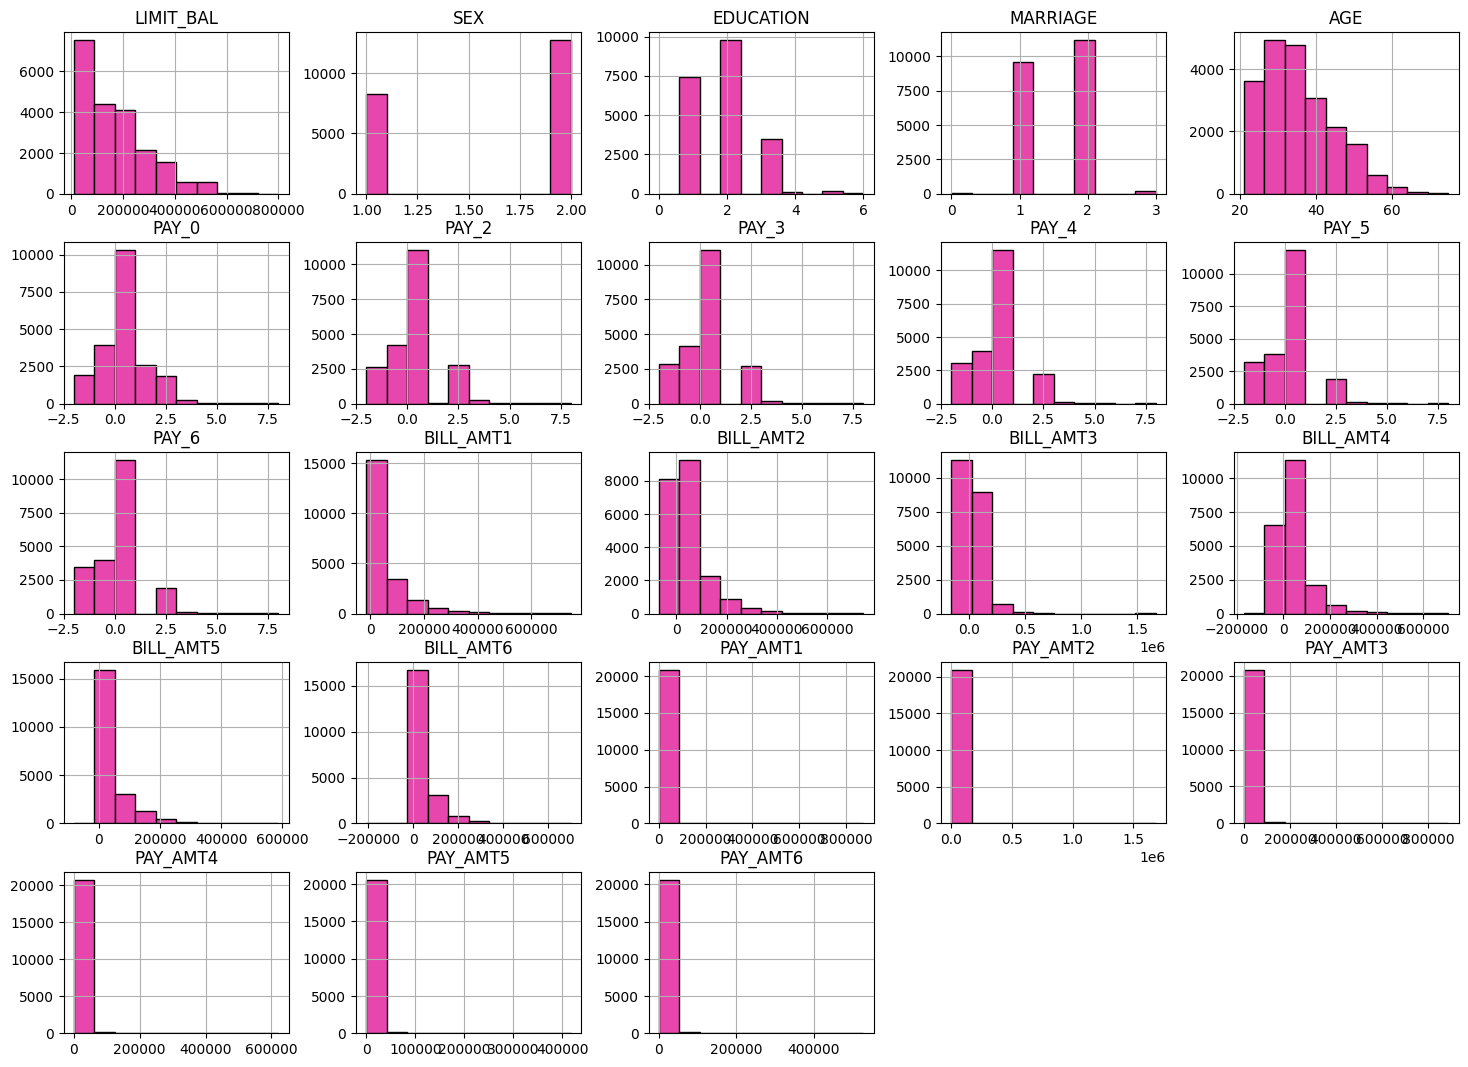

In [85]:
train.drop(columns=['ID', 'default payment next month']).hist(
    figsize=(18, 13),
    color="#e746ac",
    edgecolor='black'
)
plt.show()

### Correlation Matrix

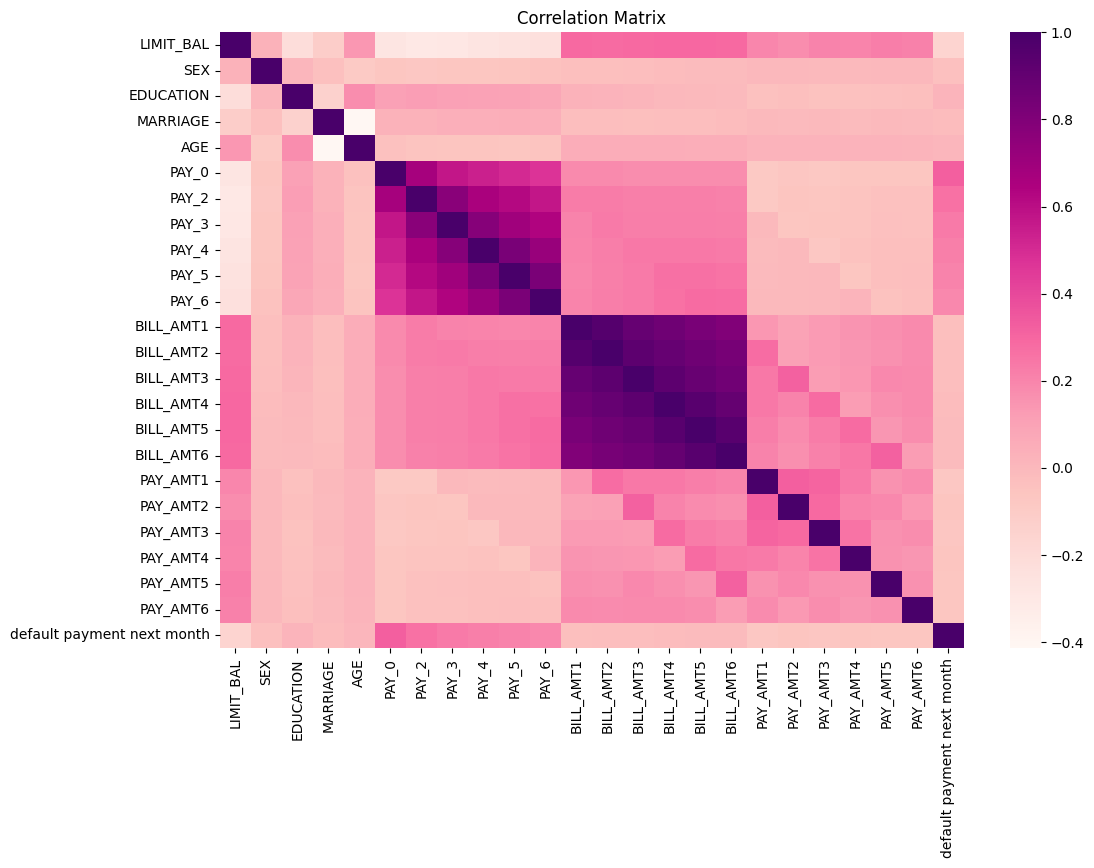

In [86]:
plt.figure(figsize=(12,8))
sns.heatmap(
    train.drop(columns=['ID']).corr(),
    cmap='RdPu'
)
plt.title("Correlation Matrix")
plt.show()

### Feature Relationships with Target

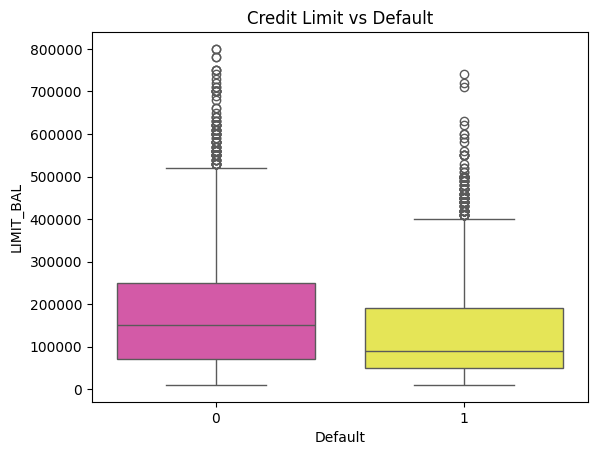

In [87]:
sns.boxplot(
    x=train['default payment next month'],
    y=train['LIMIT_BAL'],
    hue=train['default payment next month'],
    palette=['#e746ac', "#fdfd3f"],
    legend=False
)

plt.title("Credit Limit vs Default")
plt.xlabel("Default")
plt.show()

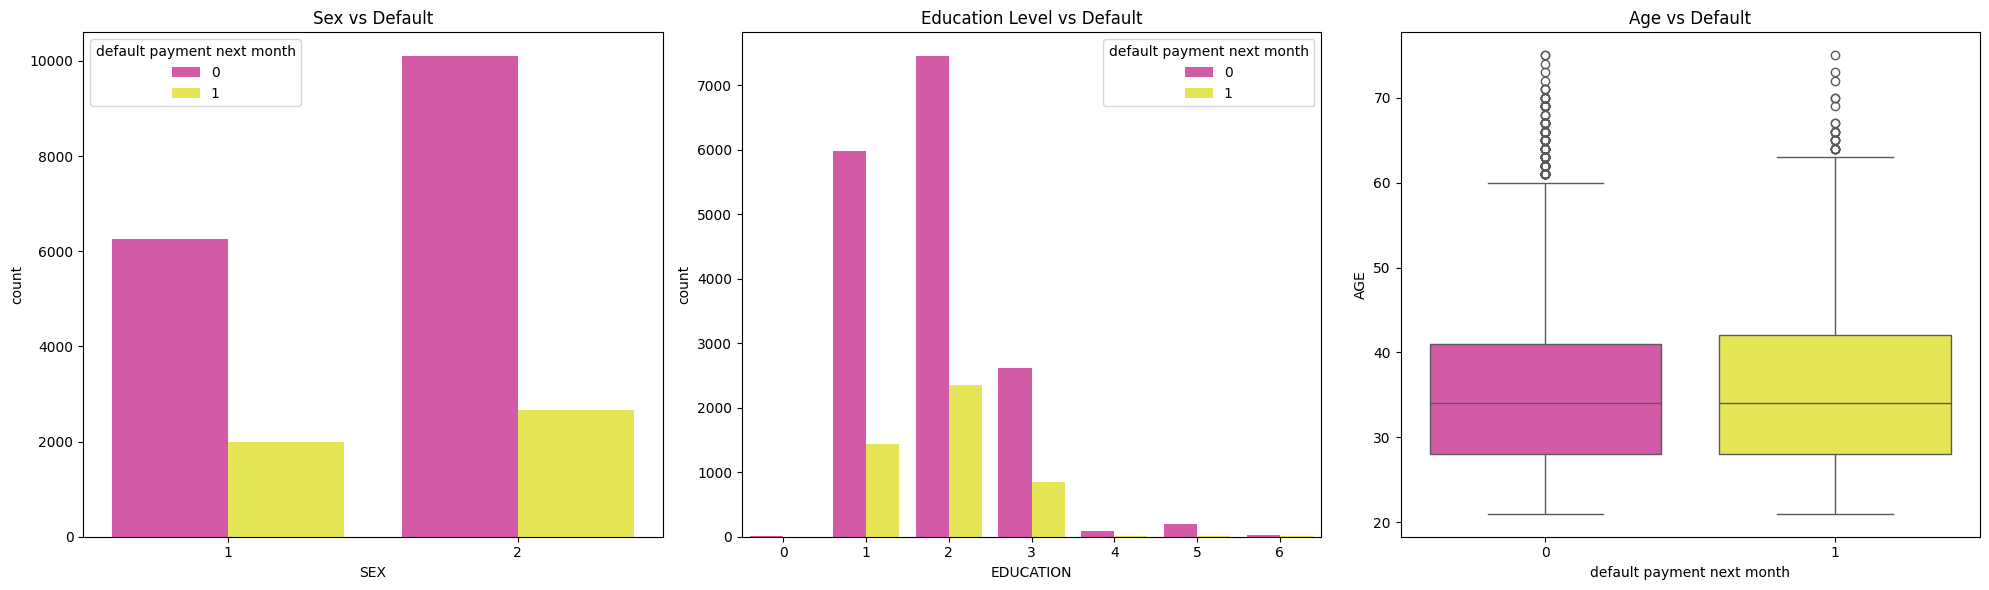

In [88]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Sex vs Default
sns.countplot(
    x='SEX', 
    hue='default payment next month', 
    data=train, 
    palette=['#e746ac', '#fdfd3f'], 
    ax=axes[0]
)
axes[0].set_title('Sex vs Default')

# 2. Education Level vs Default
sns.countplot(
    x='EDUCATION', 
    hue='default payment next month', 
    data=train, 
    palette=['#e746ac', '#fdfd3f'], 
    ax=axes[1]
)
axes[1].set_title('Education Level vs Default')

# 3. Age vs Default (Boxplot)
sns.boxplot(
    x='default payment next month', 
    y='AGE', 
    hue='default payment next month', 
    data=train, 
    palette=['#e746ac', '#fdfd3f'], 
    ax=axes[2],
    legend=False
)
axes[2].set_title('Age vs Default')

plt.tight_layout()
plt.show()

# Data Cleaning & Preprocessing

## Fix Invalid / Undocumented Category Values

## EDUCATION

In [89]:
print('EDUCATION before (train):')
print(train['EDUCATION'].value_counts().sort_index() )
train['EDUCATION'] = train['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
test['EDUCATION']  = test['EDUCATION'].replace({0: 4, 5: 4, 6: 4})
print('EDUCATION after (train):')
print(train['EDUCATION'].value_counts().sort_index())

EDUCATION before (train):
EDUCATION
0      10
1    7415
2    9789
3    3467
4      85
5     200
6      34
Name: count, dtype: int64
EDUCATION after (train):
EDUCATION
1    7415
2    9789
3    3467
4     329
Name: count, dtype: int64


## MARRIAGE

In [90]:
print("MARRIAGE before (train):")
print(train['MARRIAGE'].value_counts().sort_index())
train['MARRIAGE'] = train['MARRIAGE'].replace({0: 3})
test['MARRIAGE']  = test['MARRIAGE'].replace({0: 3})
print("MARRIAGE after (train):")
print(train['MARRIAGE'].value_counts().sort_index())

MARRIAGE before (train):
MARRIAGE
0       36
1     9561
2    11184
3      219
Name: count, dtype: int64
MARRIAGE after (train):
MARRIAGE
1     9561
2    11184
3      255
Name: count, dtype: int64


In [91]:
pay_cols = ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
print("PAY_0 before (train):")
print(train['PAY_0'].value_counts().sort_index())
for col in pay_cols:
    train[col] = train[col].replace({-2: -1})
    test[col]  = test[col].replace({-2: -1})
print("\nPAY_0 after (train):")
print(train['PAY_0'].value_counts().sort_index())

PAY_0 before (train):
PAY_0
-2     1923
-1     3937
 0    10324
 1     2608
 2     1883
 3      231
 4       47
 5       19
 6        9
 7        8
 8       11
Name: count, dtype: int64

PAY_0 after (train):
PAY_0
-1     5860
 0    10324
 1     2608
 2     1883
 3      231
 4       47
 5       19
 6        9
 7        8
 8       11
Name: count, dtype: int64


## Missing Values

In [92]:
print(train.isnull().sum())
print("Total missing:", train.isnull().sum().sum())

ID                            0
LIMIT_BAL                     0
SEX                           0
EDUCATION                     0
MARRIAGE                      0
AGE                           0
PAY_0                         0
PAY_2                         0
PAY_3                         0
PAY_4                         0
PAY_5                         0
PAY_6                         0
BILL_AMT1                     0
BILL_AMT2                     0
BILL_AMT3                     0
BILL_AMT4                     0
BILL_AMT5                     0
BILL_AMT6                     0
PAY_AMT1                      0
PAY_AMT2                      0
PAY_AMT3                      0
PAY_AMT4                      0
PAY_AMT5                      0
PAY_AMT6                      0
default payment next month    0
dtype: int64
Total missing: 0


In [93]:
# Define feature groups
categorical_cols = ['SEX', 'EDUCATION', 'MARRIAGE'] + pay_cols
numerical_cols = [c for c in train.columns if c not in categorical_cols + ['ID', 'default payment next month']]

# Learn from train
num_medians = train[numerical_cols].median()
cat_modes   = train[categorical_cols].mode().iloc[0]

# Apply on both
for df in [train, test]:
    df[numerical_cols] = df[numerical_cols].fillna(num_medians)
    df[categorical_cols] = df[categorical_cols].fillna(cat_modes)

print('Missing (train):', train.isnull().sum().sum())
print('Missing (test):', test.isnull().sum().sum())

Missing (train): 0
Missing (test): 0


## Outlier Handling (IQR Capping / Winsorization)

- Lower bound = Q1 − 1.5 × IQR  
- Upper bound = Q3 + 1.5 × IQR

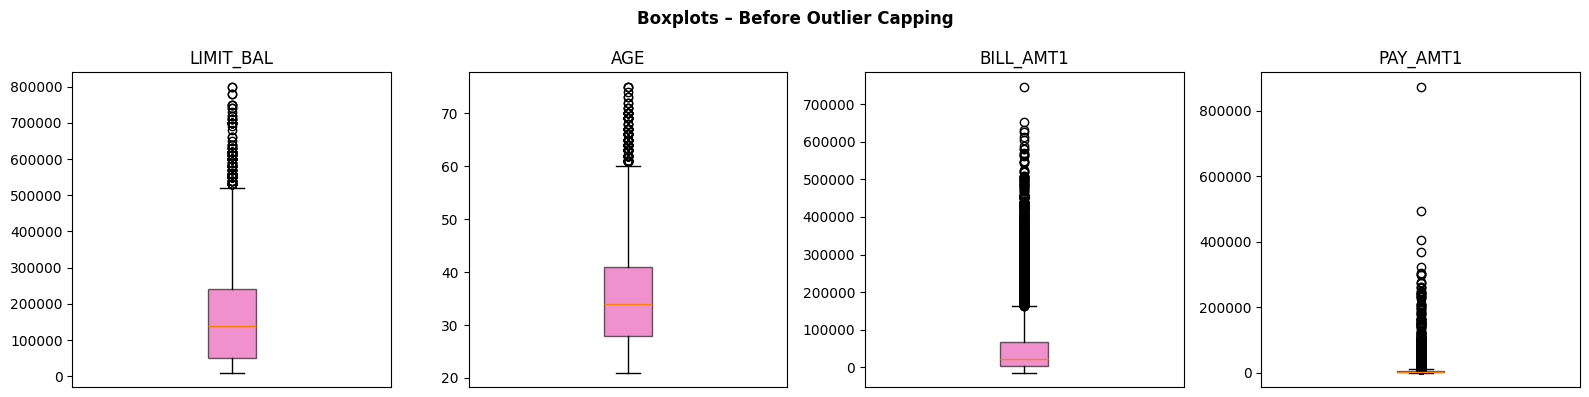

In [94]:
sample_cols = ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'PAY_AMT1']
fig, axes = plt.subplots(1, len(sample_cols), figsize=(16, 4))
for ax, col in zip(axes, sample_cols):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops={'facecolor': '#e746ac', 'alpha': 0.6})
    ax.set(title=col, xticks=[])
plt.suptitle('Boxplots – Before Outlier Capping', fontweight='bold')
plt.tight_layout()
plt.show()

In [95]:
class IQROutlierCapper:
    def __init__(self, cols, factor=1.5):
        self.cols = cols
        self.factor = factor

    def fit(self, df):
        Q1 = df[self.cols].quantile(0.25)
        Q3 = df[self.cols].quantile(0.75)
        IQR = Q3 - Q1

        self.lower_ = Q1 - self.factor * IQR
        self.upper_ = Q3 + self.factor * IQR
        return self

    def transform(self, df):
        df = df.copy()
        df[self.cols] = df[self.cols].clip(self.lower_, self.upper_, axis=1)
        return df

    def fit_transform(self, df):
        return self.fit(df).transform(df)

    def summary(self, df):
        outliers = ((df[self.cols] < self.lower_) | (df[self.cols] > self.upper_)).sum()
        return pd.DataFrame({
            'outliers': outliers,
            'lower_bound': self.lower_.round(1),
            'upper_bound': self.upper_.round(1)
        })

In [96]:
capper = IQROutlierCapper(cols=numerical_cols).fit(train)

print('Outliers BEFORE:')
print(capper.summary(train))

train, test = [capper.transform(df) for df in (train, test)]

print('\nOutliers AFTER:')
print(capper.summary(train))

Outliers BEFORE:
           outliers  lower_bound  upper_bound
LIMIT_BAL       111    -235000.0     525000.0
AGE             188          8.5         60.5
BILL_AMT1      1663     -92902.5     164343.5
BILL_AMT2      1655     -89877.4     157795.6
BILL_AMT3      1696     -84524.5     148037.5
BILL_AMT4      1789     -77235.1     134943.9
BILL_AMT5      1906     -71378.4     123654.6
BILL_AMT6      1879     -71087.6     121793.4
PAY_AMT1       1905      -5039.2      11060.8
PAY_AMT2       1903      -5410.0      11246.0
PAY_AMT3       1823      -5775.0      10665.0
PAY_AMT4       2054      -5293.4       9579.6
PAY_AMT5       2029      -5474.0       9766.0
PAY_AMT6       2063      -5745.0       9847.0

Outliers AFTER:
           outliers  lower_bound  upper_bound
LIMIT_BAL         0    -235000.0     525000.0
AGE               0          8.5         60.5
BILL_AMT1         0     -92902.5     164343.5
BILL_AMT2         0     -89877.4     157795.6
BILL_AMT3         0     -84524.5     148037.5


# Visualize after capping

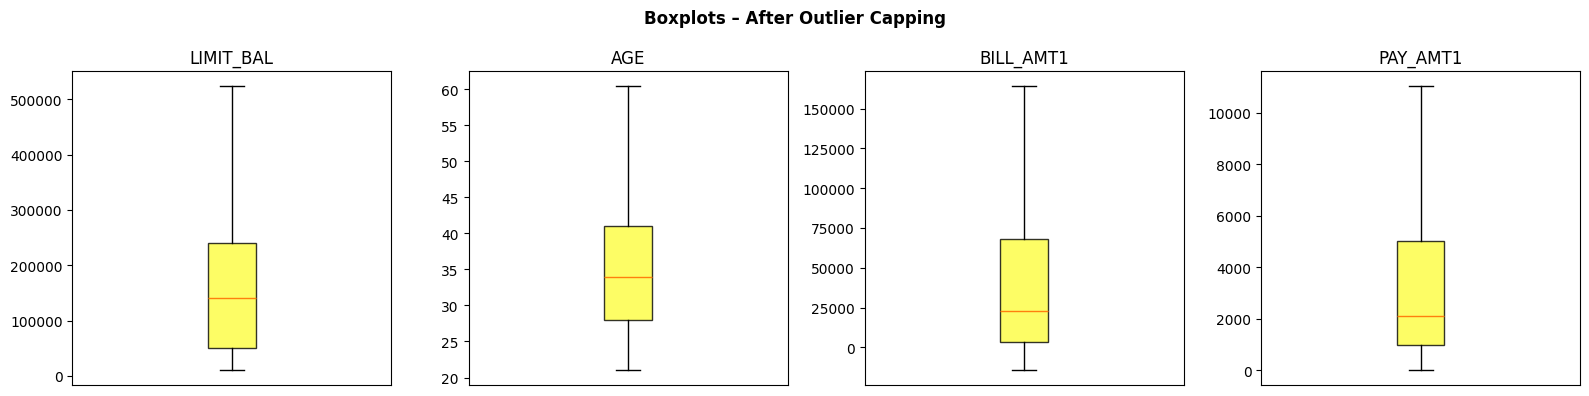

In [97]:
fig, axes = plt.subplots(1, len(sample_cols), figsize=(16, 4))
for ax, col in zip(axes, sample_cols):
    ax.boxplot(train[col].dropna(), patch_artist=True,
               boxprops={'facecolor': '#fdfd3f', 'alpha': 0.8})
    ax.set(title=col, xticks=[])
plt.suptitle('Boxplots – After Outlier Capping', fontweight='bold')
plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
# 1. Feature Engineering
for df_set in [train, test]:
    df_set['TOTAL_DELAY'] = df_set[pay_cols].apply(lambda x: x[x > 0].sum(), axis=1)
    
    df_set['UTILIZATION_RATIO'] = df_set['BILL_AMT1'] / df_set['LIMIT_BAL']
    
    bill_cols = ['BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6']
    df_set['AVG_BILL'] = df_set[bill_cols].mean(axis=1)
    
    df_set['PAY_RATIO_1'] = df_set['PAY_AMT1'] / df_set['BILL_AMT2'].replace(0, 1)

In [99]:
train.shape

(21000, 29)

## Encoding

In [100]:
train.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'TOTAL_DELAY', 'UTILIZATION_RATIO',
       'AVG_BILL', 'PAY_RATIO_1'],
      dtype='object')

In [101]:
train['SEX'] = train['SEX'].map({1: 0, 2: 1})
test['SEX']  = test['SEX'].map({1: 0, 2: 1})
print("SEX unique values after encoding:", train['SEX'].unique())

SEX unique values after encoding: [1 0]


# MARRIAGE: One Hot Encoding

In [102]:
marriage_categories = sorted(train['MARRIAGE'].unique())
def ohe_marriage(df, categories):
    dummies = pd.get_dummies(
        pd.Categorical(df['MARRIAGE'], categories=categories),
        prefix='MARRIAGE'
    )
    dummies.index = df.index
    return pd.concat([df.drop(columns=['MARRIAGE']), dummies], axis=1)

train = ohe_marriage(train, marriage_categories)
test  = ohe_marriage(test,  marriage_categories)

print("MARRIAGE columns after OHE:",
      [c for c in train.columns if 'MARRIAGE' in c])
print("Train shape after OHE:", train.shape)

MARRIAGE columns after OHE: ['MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3']
Train shape after OHE: (21000, 31)


In [103]:
train.columns


Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3',
       'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3',
       'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2',
       'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6',
       'default payment next month', 'TOTAL_DELAY', 'UTILIZATION_RATIO',
       'AVG_BILL', 'PAY_RATIO_1', 'MARRIAGE_1', 'MARRIAGE_2', 'MARRIAGE_3'],
      dtype='object')

## Preprocessing Summary

In [104]:
print("    DATA CLEANING & PREPROCESSING SUMMARY")
print(f"  Records dropped        : 0")
print(f"  Missing values remain  : {train.isnull().sum().sum()}")
print(f"  Train shape            : {train.shape}")
print(f"  Test  shape            : {test.shape}")
train.head()

    DATA CLEANING & PREPROCESSING SUMMARY
  Records dropped        : 0
  Missing values remain  : 0
  Train shape            : (21000, 31)
  Test  shape            : (9000, 31)


,ID,LIMIT_BAL,SEX,EDUCATION,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,...,PAY_AMT5,PAY_AMT6,default payment next month,TOTAL_DELAY,UTILIZATION_RATIO,AVG_BILL,PAY_RATIO_1,MARRIAGE_1,MARRIAGE_2,MARRIAGE_3
25149,25150,360000,1,2,25.0,-1,-1,-1,-1,-1,...,2020,9847,0,0,0.058200,8557.666667,0.878535,False,True,False
13469,13470,240000,1,1,46.0,2,2,-1,-1,0,...,2267,3074,0,4,0.001900,1107.333333,0.000000,False,True,False
3091,3092,320000,1,2,41.0,0,0,0,0,0,...,3000,1500,0,0,0.155769,41459.666667,0.092918,True,False,False
13972,13973,50000,1,2,24.0,-1,-1,-1,-1,-1,...,0,0,1,0,0.053500,445.833333,0.000000,False,True,False
10566,10567,80000,0,3,52.0,-1,0,0,0,0,...,876,1449,0,0,0.448263,22841.000000,0.080989,True,False,False


# Feature Scaling + Prep for Modeling

In [105]:
# Drop ID (not a feature)
train_clean = train.drop(columns=['ID'])
test_clean  = test.drop(columns=['ID'])

TARGET = 'default payment next month'

X_train = train_clean.drop(columns=[TARGET])
y_train = train_clean[TARGET]

X_test  = test_clean.drop(columns=[TARGET])
y_test  = test_clean[TARGET]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (21000, 29)
X_test : (9000, 29)


# Feature Scaling (StandardScaler)

In [106]:
# Don't scale binary or ordinal categorical columns
binary_cols = ['SEX'] + [c for c in X_train.columns if c.startswith('MARRIAGE_')]
pay_cols    = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

cols_to_scale = [c for c in X_train.columns if c not in binary_cols + pay_cols]

scaler = StandardScaler()

X_train_scaled = X_train.copy().astype(float)
X_test_scaled  = X_test.copy().astype(float)

# Fit on train only → apply to both
X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])

print("Scaled columns :", cols_to_scale)
print("X_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)

Scaled columns : ['LIMIT_BAL', 'EDUCATION', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'TOTAL_DELAY', 'UTILIZATION_RATIO', 'AVG_BILL', 'PAY_RATIO_1']
X_train_scaled : (21000, 29)
X_test_scaled  : (9000, 29)


# Feature Correlation with Target

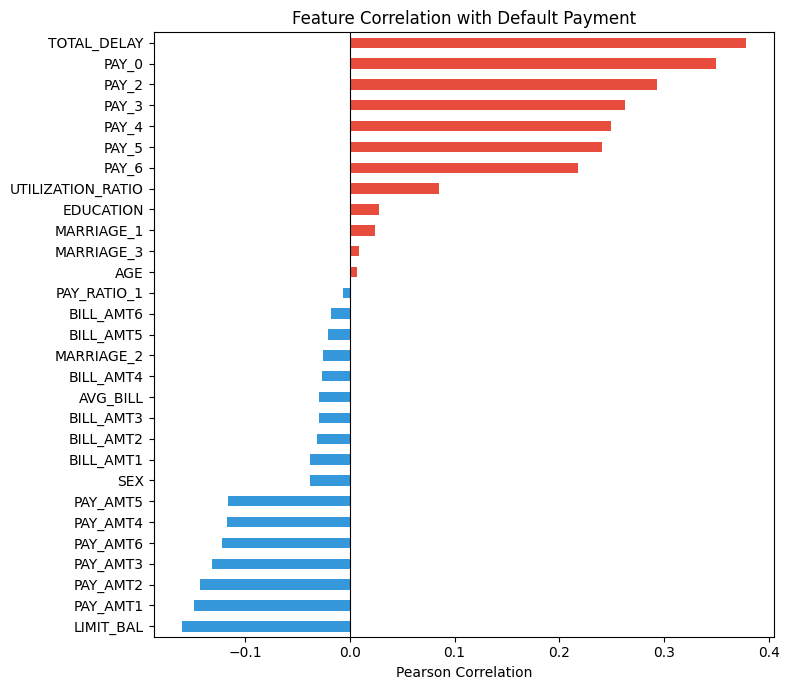

In [107]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_df = X_train_scaled.copy()
corr_df[TARGET] = y_train.values

corr = corr_df.corr()[TARGET].drop(TARGET).sort_values()

plt.figure(figsize=(8, 7))
colors = ['#e74c3c' if v > 0 else '#3498db' for v in corr]
corr.plot(kind='barh', color=colors)
plt.title("Feature Correlation with Default Payment")
plt.xlabel("Pearson Correlation")
plt.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

# Key Features vs Default (Boxplots)

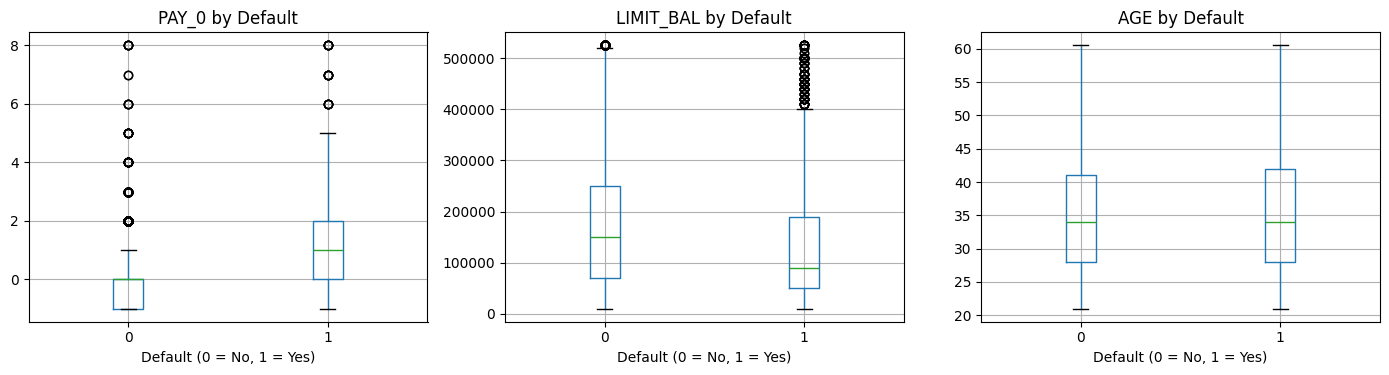

In [108]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, col in zip(axes, ['PAY_0', 'LIMIT_BAL', 'AGE']):
    train_clean.boxplot(column=col, by=TARGET, ax=ax)
    ax.set_title(f"{col} by Default")
    ax.set_xlabel("Default (0 = No, 1 = Yes)")

plt.suptitle("")
plt.tight_layout()
plt.show()

# Summary

In [109]:
print(f"Total features for modeling : {X_train_scaled.shape[1]}")
print(f"Columns scaled              : {len(cols_to_scale)}")
print(f"Columns NOT scaled          : {len(binary_cols + pay_cols)}")
print(f"X_train_scaled shape        : {X_train_scaled.shape}")
print(f"X_test_scaled  shape        : {X_test_scaled.shape}")
print(f"\ny_train distribution:")
print(y_train.value_counts(normalize=True).round(3))

Total features for modeling : 29
Columns scaled              : 19
Columns NOT scaled          : 10
X_train_scaled shape        : (21000, 29)
X_test_scaled  shape        : (9000, 29)

y_train distribution:
default payment next month
0    0.779
1    0.221
Name: proportion, dtype: float64


# Dimensionality Reduction (PCA)

## Why PCA?
With ~26 features (after OHE) many of which are correlated payment/bill amounts, PCA can remove multicollinearity, speed up SVM training, and help us visualise the decision boundary.

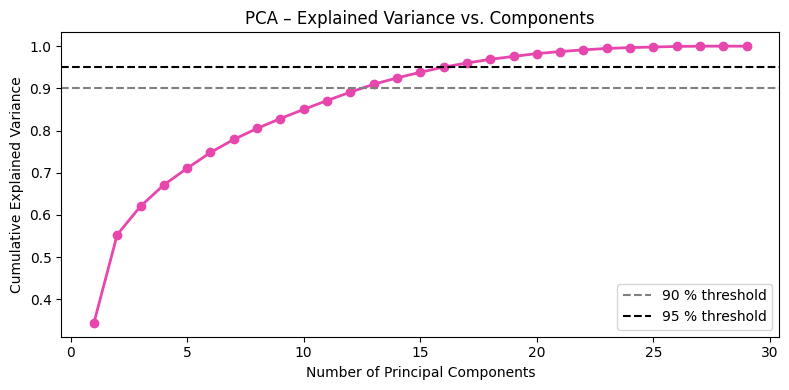

Components to retain 90 % variance : 13
Components to retain 95 % variance : 16


In [110]:
# ── 1. Explained variance curve ──────────────────────────────────────────────
pca_full = PCA(random_state=42)   #keep all features as n_components is none 
pca_full.fit(X_train_scaled)      # here 

cumvar = np.cumsum(pca_full.explained_variance_ratio_)    # total of keeped information  up to K components : 
#computes the cumulative explained variance, showing how much total information is preserved as more principal components are adde
#portiant of variance  for each component lambda1/total variance


plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='#e746ac', linewidth=2)
plt.axhline(0.90, color='gray', linestyle='--', label='90 % threshold')
plt.axhline(0.95, color='black', linestyle='--', label='95 % threshold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA – Explained Variance vs. Components')
plt.legend()
plt.tight_layout()
plt.show()

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1
print(f"Components to retain 90 % variance : {n_90}")
print(f"Components to retain 95 % variance : {n_95}")


## Apply PCA – retain 95 % variance

In [111]:
N_COMPONENTS = n_95          # set by the cell above

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)       #dim reduction + projection
X_test_pca  = pca.transform(X_test_scaled)  

print(f"Original feature count  : {X_train_scaled.shape[1]}")
print(f"Reduced feature count   : {X_train_pca.shape[1]}")
print(f"X_train_pca shape       : {X_train_pca.shape}")
print(f"X_test_pca  shape       : {X_test_pca.shape}")


Original feature count  : 29
Reduced feature count   : 16
X_train_pca shape       : (21000, 16)
X_test_pca  shape       : (9000, 16)


# SVM Model

In [112]:
svm_param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01],
    'kernel': ['rbf'] }

In [113]:
grid_search = GridSearchCV(
    SVC(class_weight='balanced', random_state=42),
    svm_param_grid,
    cv=5,            
    scoring='f1_macro',   
    n_jobs=-1       
)

In [114]:
grid_search.fit(X_train_pca, y_train)

best_svm = grid_search.best_estimator_

print(f"Best Parameters: {grid_search.best_params_}")

Best Parameters: {'C': 10, 'gamma': 0.01, 'kernel': 'rbf'}


In [115]:
y_pred = best_svm.predict(X_test_pca)

print("Final Evaluation Metrics:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred))

Final Evaluation Metrics:
Accuracy: 0.7762

Detailed Report:
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      7009
           1       0.50      0.57      0.53      1991

    accuracy                           0.78      9000
   macro avg       0.68      0.70      0.69      9000
weighted avg       0.79      0.78      0.78      9000



In [131]:
print(scaler.feature_names_in_)

['LIMIT_BAL' 'EDUCATION' 'AGE' 'BILL_AMT1' 'BILL_AMT2' 'BILL_AMT3'
 'BILL_AMT4' 'BILL_AMT5' 'BILL_AMT6' 'PAY_AMT1' 'PAY_AMT2' 'PAY_AMT3'
 'PAY_AMT4' 'PAY_AMT5' 'PAY_AMT6' 'TOTAL_DELAY' 'UTILIZATION_RATIO'
 'AVG_BILL' 'PAY_RATIO_1']


In [146]:
# --- 1. Feature Engineering Function ---
def feature_engineering(df):
    df = df.copy()
    
    bill_cols = [f'BILL_AMT{i}' for i in range(1, 7)]
    pay_cols = [f'PAY_AMT{i}' for i in range(1, 7)]
    
    # Features جديدة
    df['TOTAL_DELAY'] = 0  
    df['UTILIZATION_RATIO'] = df['BILL_AMT1'] / df['LIMIT_BAL']
    df['AVG_BILL'] = df[bill_cols].mean(axis=1)
    df['PAY_RATIO_1'] = df['PAY_AMT1'] / df['BILL_AMT1'].replace(0, 1)
    
    # تعويض NaN
    df = df.replace([np.inf, -np.inf], 0).fillna(0)
    
    return df

# --- 2. Pipeline ---
X_train_fe = feature_engineering(X_train)

pipeline = Pipeline([
    ('scaler', scaler),
    ('pca', pca),
    ('model', best_svm)
])

pipeline.fit(X_train_fe, y_train)
feature_order = X_train_fe.columns.tolist()

# --- Save everything ---
model_package = {
    "pipeline": pipeline,
    "columns": feature_order
}

pickle.dump(model_package, open("model.pkl", "wb"))


# Evaluation

In [139]:
print("=" * 55)
print("         FINAL EVALUATION — SVM (RBF kernel)")
print("=" * 55)
print(f"  Accuracy  : {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred,
      target_names=['No default (0)', 'Default (1)']))

         FINAL EVALUATION — SVM (RBF kernel)
  Accuracy  : 0.7762

                precision    recall  f1-score   support

No default (0)       0.87      0.83      0.85      7009
   Default (1)       0.50      0.57      0.53      1991

      accuracy                           0.78      9000
     macro avg       0.68      0.70      0.69      9000
  weighted avg       0.79      0.78      0.78      9000



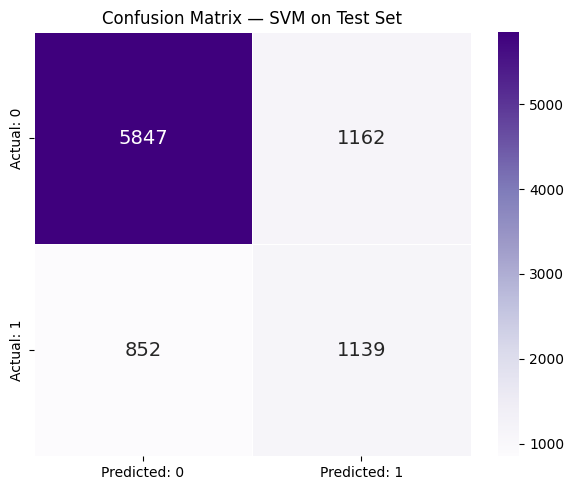

In [140]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Predicted: 0', 'Predicted: 1'],
            yticklabels=['Actual: 0',    'Actual: 1'],
            linewidths=0.5, annot_kws={'size': 14})
plt.title('Confusion Matrix — SVM on Test Set')
plt.tight_layout()
plt.show()

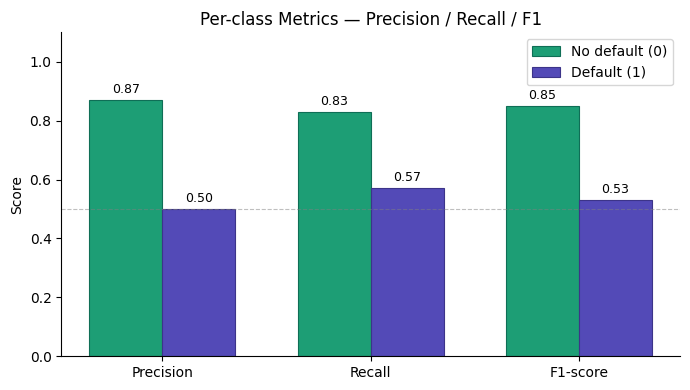

In [141]:
metrics = ['Precision', 'Recall', 'F1-score']
class0  = [0.87, 0.83, 0.85]
class1  = [0.50, 0.57, 0.53]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 4))
b0 = ax.bar(x - width/2, class0, width, label='No default (0)',
            color='#1D9E75', edgecolor='#0F6E56', linewidth=0.8)
b1 = ax.bar(x + width/2, class1, width, label='Default (1)',
            color='#534AB7', edgecolor='#3C3489', linewidth=0.8)

ax.set_ylim(0, 1.1)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.set_title('Per-class Metrics — Precision / Recall / F1')
ax.legend()
ax.bar_label(b0, fmt='%.2f', padding=3, fontsize=9)
ax.bar_label(b1, fmt='%.2f', padding=3, fontsize=9)
ax.axhline(0.5, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

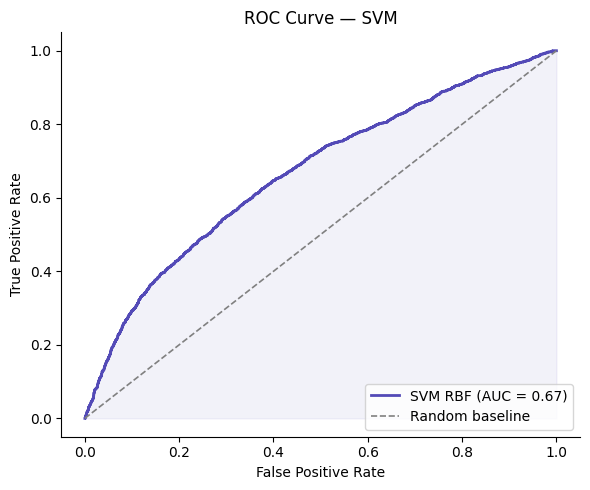


ROC-AUC Score: 0.6676


In [143]:
scores = best_svm.decision_function(X_test_pca)
fpr, tpr, _ = roc_curve(y_test, scores)
auc = roc_auc_score(y_test, scores)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='#534AB7', lw=2,
         label=f'SVM RBF (AUC = {auc:.2f})')
plt.plot([0,1],[0,1], color='gray', lw=1.2,
         linestyle='--', label='Random baseline')
plt.fill_between(fpr, tpr, alpha=0.07, color='#534AB7')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — SVM')
plt.legend(loc='lower right')
plt.gca().spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nROC-AUC Score: {auc:.4f}")